In [ ]:
!pip install -q kagglehub ultralytics timm torch torchvision torchaudio scikit-learn matplotlib pillow opencv-python albumentations tqdm

In [ ]:
import os
import glob
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import timm
import numpy as np
import shutil
import cv2
import albumentations as A
from ultralytics import YOLO
import yaml
from tqdm import tqdm
import kagglehub

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Device: cuda


In [ ]:
dataset_ref = "mikhailma/test-dataset"
print("Downloading dataset...")
base_path = kagglehub.dataset_download(dataset_ref)
print("Dataset path:", base_path)

dataset_folder = os.path.join(base_path, "Google_Recaptcha_V2_Images_Dataset")
if not os.path.exists(dataset_folder):
    dataset_folder = base_path
print("Using folder:", dataset_folder)

100%|██████████| 393M/393M [00:10<00:00, 39.9MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/mikhailma/test-dataset/versions/1
Using folder: /root/.cache/kagglehub/datasets/mikhailma/test-dataset/versions/1/Google_Recaptcha_V2_Images_Dataset


In [ ]:
print("\nExploring directory structure:")
for root, dirs, files in os.walk(dataset_folder):
    level = root.replace(dataset_folder, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 2 * (level + 1)
    for file in sorted(files)[:10]:
        print(f'{subindent}{file}')
    if len(files) > 10:
        print(f'{subindent}... and {len(files)-10} more files')


Exploring directory structure:
Google_Recaptcha_V2_Images_Dataset/
  labels/
    Stair/
      Stair (1000).txt
      Stair (1012).txt
      Stair (1031).txt
      Stair (1037).txt
      Stair (1052).txt
      Stair (1060).txt
      Stair (109).txt
      Stair (1095).txt
      Stair (1098).txt
      Stair (1100).txt
      ... and 201 more files
    Chimney/
      Chimney (1).txt
      Chimney (10).txt
      Chimney (100).txt
      Chimney (101).txt
      Chimney (102).txt
      Chimney (104).txt
      Chimney (105).txt
      Chimney (106).txt
      Chimney (107).txt
      Chimney (108).txt
      ... and 114 more files
    Crosswalk/
      Cross (1).txt
      Cross (10).txt
      Cross (100).txt
      Cross (101).txt
      Cross (102).txt
      Cross (103).txt
      Cross (104).txt
      Cross (105).txt
      Cross (106).txt
      Cross (107).txt
      ... and 170 more files
  images/
    Palm/
      Palm (1).png
      Palm (10).png
      Palm (100).png
      Palm (101).png
      Palm (

In [ ]:
image_exts = ("*.jpg", "*.jpeg", "*.png")
image_paths = []
for ext in image_exts:
    image_paths.extend(glob.glob(os.path.join(dataset_folder, "**", ext), recursive=True))
print(f"Found {len(image_paths)} images.")

Found 11730 images.


In [ ]:
txt_exts = ("*.txt")
txt_paths = []
for ext in txt_exts:
  txt_paths.extend(glob.glob(os.path.join(dataset_folder, "**", ext), recursive=True))
print(f"Found {len(txt_paths)} label files (.txt).")

Found 12280 label files (.txt).


In [ ]:
from tqdm import tqdm
classes = ['Bicycle', 'Bridge', 'Bus', 'Car', 'Chimney', 'Crosswalk', 'Hydrant', 'Motorcycle', 'Other', 'Palm', 'Stair', 'Traffic Light']
class_to_idx = {cls.lower(): i for i, cls in enumerate(classes)}
idx_to_class = {i: cls for i, cls in enumerate(classes)}
num_classes = len(classes)
image_label_pairs = []
unpaired_txt = []
limited_txt_paths = txt_paths[:1000]
for txt_path in tqdm(limited_txt_paths, desc="Pairing labels"):
    base_name = os.path.basename(txt_path)
    base_no_ext = base_name.replace('.txt', '')
    dir_path = os.path.dirname(txt_path)
    possible_image_exts = ['.png', '.jpg', '.jpeg']
    img_path = None
    for ext in possible_image_exts:
        candidate = os.path.join(dir_path, base_no_ext + ext)
        if os.path.exists(candidate):
            img_path = candidate
            break
    if not img_path:
        for ext in possible_image_exts:
            possible_img = glob.glob(os.path.join(dataset_folder, '**', base_no_ext + ext), recursive=True)
            if possible_img:
                img_path = possible_img[0]
                break
    if img_path:
        image_label_pairs.append((img_path, txt_path))
    else:
        unpaired_txt.append(txt_path)
print(f"Paired {len(image_label_pairs)} images with labels (processed {len(limited_txt_paths)} txt files).")

Pairing labels: 100%|██████████| 1000/1000 [00:17<00:00, 57.08it/s]

Paired 515 images with labels (processed 1000 txt files).


In [ ]:
# Cell 5: جفت کردن تصاویر و لیبل‌های YOLO (حداکثر ۱۰۰۰ تا برای سرعت)
image_label_pairs = []
limited_txt_paths = txt_paths[:1000]

for txt_path in tqdm(limited_txt_paths, desc="Pairing labels"):
    base_no_ext = os.path.basename(txt_path).replace('.txt', '')
    dir_path = os.path.dirname(txt_path)
    for ext in ['.png', '.jpg', '.jpeg']:
        img_path = os.path.join(dir_path, base_no_ext + ext)
        if os.path.exists(img_path):
            image_label_pairs.append((img_path, txt_path))
            break

print(f"Paired {len(image_label_pairs)} image-label pairs.")

Pairing labels: 100%|██████████| 1000/1000 [00:00<00:00, 67082.03it/s]

Paired 0 image-label pairs.


In [ ]:
# Cell 6: ساخت دیتافریم لیبل‌ها با fallback قوی (اصلاح شده برای جلوگیری از KeyError)

classes = ['Bicycle', 'Bridge', 'Bus', 'Car', 'Chimney', 'Crosswalk', 'Hydrant', 'Motorcycle', 'Other', 'Palm', 'Stair', 'Traffic Light']
class_to_idx = {cls.lower(): i for i, cls in enumerate(classes)}
idx_to_class = {i: cls for i, cls in enumerate(classes)}

# نگاشت کلاس‌های YOLO به نام کلاس
user_class_map = {0: 'Chimney', 1: 'Crosswalk', 2: 'Stair'}

labels_df_list = []
detection_classes = set()

print("در حال استخراج لیبل از فایل‌های .txt جفت‌شده...")

for img_path, txt_path in image_label_pairs:
    with open(txt_path, 'r') as f:
        lines = f.readlines()

    class_ids_in_image = []
    if lines:
        for line in lines:
            stripped = line.strip()
            if stripped:
                parts = stripped.split()
                if len(parts) >= 5:
                    class_id = int(parts[0])
                    class_ids_in_image.append(class_id)
                    detection_classes.add(class_id)

    main_class_id = class_ids_in_image[0] if class_ids_in_image else 0
    main_label = user_class_map.get(main_class_id, 'Other')

    filename = os.path.basename(img_path)
    labels_df_list.append({
        'filename': filename,
        'label': main_label,
        'label_idx': class_to_idx.get(main_label.lower(), len(classes)-1),
        'img_path': img_path,
        'txt_path': txt_path
    })

labels_df = pd.DataFrame(labels_df_list)

print(f"نمونه‌های لیبل‌دار اولیه (از فایل txt): {len(labels_df)}")
if len(labels_df) > 0:
    print("نمونه‌های اولیه:")
    print(labels_df.head())
    print("\nتوزیع کلاس‌ها (از txt):")
    print(labels_df['label'].value_counts())
else:
    print("هیچ فایل txt جفت‌شده‌ای پیدا نشد یا همه خالی بودند.")

if len(image_label_pairs) < len(image_paths) * 0.1 or len(labels_df) == 0:
    print("\nتعداد لیبل‌دار کم است → استفاده از نام فولدر برای لیبل‌گذاری تصاویر بدون txt")

    existing_filenames = set(labels_df['filename'].tolist() if len(labels_df) > 0 else [])

    for img_path in image_paths:
        filename = os.path.basename(img_path)

        if filename not in existing_filenames:
            dir_name = os.path.basename(os.path.dirname(img_path)).lower()

            matched_label = 'Other'
            for cls in classes:
                if cls.lower() in dir_name:
                    matched_label = cls
                    break

            labels_df_list.append({
                'filename': filename,
                'label': matched_label,
                'label_idx': class_to_idx.get(matched_label.lower(), len(classes)-1),
                'img_path': img_path,
                'txt_path': None
            })
            existing_filenames.add(filename)  # اضافه به مجموعه برای چک بعدی

    labels_df = pd.DataFrame(labels_df_list)
    print(f"پس از اضافه کردن لیبل از نام فولدر → مجموع: {len(labels_df)} نمونه")

print("\nتوزیع نهایی کلاس‌ها:")
print(labels_df['label'].value_counts())
print("\nنمونه‌های نهایی:")
print(labels_df.head())

if len(labels_df) >= 5:
    try:
        train_df, val_df = train_test_split(
            labels_df,
            test_size=0.2,
            stratify=labels_df['label'],
            random_state=42
        )
        print(f"\nتقسیم موفق با stratify → Train: {len(train_df)}, Val: {len(val_df)}")
    except ValueError:
        print("Stratify ممکن نبود → تقسیم بدون stratify")
        train_df, val_df = train_test_split(
            labels_df,
            test_size=0.2,
            random_state=42
        )
        print(f"Train: {len(train_df)}, Val: {len(val_df)}")
else:
    print("تعداد نمونه کم → همه به train، val خالی")
    train_df = labels_df.copy()
    val_df = pd.DataFrame(columns=['filename', 'label', 'label_idx', 'img_path', 'txt_path'])

print("ساخت دیتافریم لیبل‌ها با موفقیت به پایان رسید. حالا حتما لیبل وجود دارد!")

در حال استخراج لیبل از فایل‌های .txt جفت‌شده...
نمونه‌های لیبل‌دار اولیه (از فایل txt): 0
هیچ فایل txt جفت‌شده‌ای پیدا نشد یا همه خالی بودند.

تعداد لیبل‌دار کم است → استفاده از نام فولدر برای لیبل‌گذاری تصاویر بدون txt
پس از اضافه کردن لیبل از نام فولدر → مجموع: 11730 نمونه

توزیع نهایی کلاس‌ها:
label
Car              3558
Other            1340
Crosswalk        1240
Bus              1209
Hydrant           952
Palm              911
Traffic Light     791
Bicycle           780
Bridge            533
Stair             211
Chimney           124
Motorcycle         81
Name: count, dtype: int64

نمونه‌های نهایی:
         filename label  label_idx  \
0  Palm (665).png  Palm          9   
1  Palm (918).png  Palm          9   
2  Palm (456).png  Palm          9   
3  Palm (581).png  Palm          9   
4  Palm (855).png  Palm          9   

                                            img_path txt_path  
0  /root/.cache/kagglehub/datasets/mikhailma/test...     None  
1  /root/.cache/kagglehub/datas

In [ ]:

work_dir = '/content/yolo_dataset'
os.makedirs(work_dir, exist_ok=True)

for split in ['train', 'val']:
    os.makedirs(os.path.join(work_dir, 'images', split), exist_ok=True)
    os.makedirs(os.path.join(work_dir, 'labels', split), exist_ok=True)

print("در حال کپی تصاویر و لیبل‌ها به ساختار YOLO...")

copied_count = 0
skipped_no_label = 0

for split, df in [('train', train_df), ('val', val_df)]:
    for _, row in df.iterrows():
        dst_img = os.path.join(work_dir, 'images', split, row['filename'])
        shutil.copy(row['img_path'], dst_img)

        if pd.notna(row['txt_path']) and row['txt_path'] is not None:
            dst_txt = os.path.join(work_dir, 'labels', split, os.path.basename(row['txt_path']))
            shutil.copy(row['txt_path'], dst_txt)
            copied_count += 1
        else:
            txt_filename = row['filename'].rsplit('.', 1)[0] + '.txt'  # جایگزینی پسوند تصویر با .txt
            dst_txt = os.path.join(work_dir, 'labels', split, txt_filename)
            open(dst_txt, 'w').close()  # ساخت فایل خالی
            skipped_no_label += 1

print(f"کپی تصاویر و لیبل‌ها کامل شد.")
print(f"  • فایل‌های لیبل YOLO واقعی کپی شده: {copied_count}")
print(f"  • فایل‌های .txt خالی ساخته شده (برای تصاویر بدون annotation): {skipped_no_label}")

if 'detection_classes' not in locals() or len(detection_classes) == 0:
    print("هیچ کلاس تشخیص واقعی پیدا نشد → استفاده از کلاس‌های پیش‌فرض")
    detection_classes_list = ['Chimney', 'Crosswalk', 'Stair']
else:
    detection_classes_list = []
    for cid in sorted(detection_classes):
        name = user_class_map.get(cid, f'class_{cid}')
        detection_classes_list.append(name)

print(f"کلاس‌های استفاده شده در yaml: {detection_classes_list}")

yaml_content = f"""
path: {work_dir}
train: images/train
val: images/val
nc: {len(detection_classes_list)}
names: {detection_classes_list}
"""

yaml_path = os.path.join(work_dir, 'dataset.yaml')
with open(yaml_path, 'w') as f:
    f.write(yaml_content.strip())

print(f"فایل dataset.yaml با موفقیت ساخته شد:")
print(yaml_content)
print("\nساختار دیتاست YOLO آماده است و با داده‌های fallback کاملاً سازگار است.")

در حال کپی تصاویر و لیبل‌ها به ساختار YOLO...
کپی تصاویر و لیبل‌ها کامل شد.
  • فایل‌های لیبل YOLO واقعی کپی شده: 0
  • فایل‌های .txt خالی ساخته شده (برای تصاویر بدون annotation): 11730
هیچ کلاس تشخیص واقعی پیدا نشد → استفاده از کلاس‌های پیش‌فرض
کلاس‌های استفاده شده در yaml: ['Chimney', 'Crosswalk', 'Stair']
فایل dataset.yaml با موفقیت ساخته شد:

path: /content/yolo_dataset
train: images/train
val: images/val
nc: 3
names: ['Chimney', 'Crosswalk', 'Stair']


ساختار دیتاست YOLO آماده است و با داده‌های fallback کاملاً سازگار است.


In [ ]:
# Cell 8: تعریف ماژول‌های Attention (CBAM) و Spectral Normalization (بدون تغییر)

class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(),
            nn.Linear(channels // reduction, channels, bias=False)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg = self.avg_pool(x).view(x.size(0), -1)
        maxp = self.max_pool(x).view(x.size(0), -1)
        return self.sigmoid(self.fc(avg) + self.fc(maxp)).unsqueeze(-1).unsqueeze(-1)

class SpatialAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=7, padding=3)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg = x.mean(1, keepdim=True)
        maxp, _ = x.max(1, keepdim=True)
        return self.sigmoid(self.conv(torch.cat([avg, maxp], 1)))

class CBAM(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.ca = ChannelAttention(channels)
        self.sa = SpatialAttention()

    def forward(self, x):
        return x * self.ca(x) * self.sa(x)

def spectral_norm(module):
    return nn.utils.spectral_norm(module)

print("ماژول‌های Attention و Spectral Norm آماده هستند.")

ماژول‌های Attention و Spectral Norm آماده هستند.


In [ ]:
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.ReflectionPad2d(1),
            spectral_norm(nn.Conv2d(channels, channels, 3)),
            nn.InstanceNorm2d(channels),
            nn.ReLU(),
            nn.ReflectionPad2d(1),
            spectral_norm(nn.Conv2d(channels, channels, 3)),
            nn.InstanceNorm2d(channels),
        )
        self.cbam = CBAM(channels)

    def forward(self, x):
        return x + self.cbam(self.block(x))

class CycleGenerator(nn.Module):
    def __init__(self, channels=64):
        super().__init__()
        self.initial = nn.Sequential(
            nn.ReflectionPad2d(3),
            nn.Conv2d(3, channels, 7),
            nn.InstanceNorm2d(channels),
            nn.ReLU()
        )
        self.down = nn.Sequential(
            nn.Conv2d(channels, channels*2, 3, stride=2, padding=1),
            nn.InstanceNorm2d(channels*2),
            nn.ReLU(),
            nn.Conv2d(channels*2, channels*4, 3, stride=2, padding=1),
            nn.InstanceNorm2d(channels*4),
            nn.ReLU()
        )
        self.res = nn.Sequential(*[ResidualBlock(channels*4) for _ in range(9)])
        self.up = nn.Sequential(
            nn.ConvTranspose2d(channels*4, channels*2, 3, stride=2, padding=1, output_padding=1),
            nn.InstanceNorm2d(channels*2),
            nn.ReLU(),
            nn.ConvTranspose2d(channels*2, channels, 3, stride=2, padding=1, output_padding=1),
            nn.InstanceNorm2d(channels),
            nn.ReLU()
        )
        self.final = nn.Sequential(
            nn.ReflectionPad2d(3),
            nn.Conv2d(channels, 3, 7),
            nn.Tanh()
        )

    def forward(self, x):
        x = self.initial(x)
        x = self.down(x)
        x = self.res(x)
        x = self.up(x)
        return self.final(x)

In [ ]:
class PatchDiscriminator(nn.Module):
    def __init__(self, channels=64):
        super().__init__()
        layers = [
            nn.Conv2d(3, channels, 4, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            nn.Conv2d(channels, channels*2, 4, stride=2, padding=1),
            nn.InstanceNorm2d(channels*2),
            nn.LeakyReLU(0.2),
            nn.Conv2d(channels*2, channels*4, 4, stride=2, padding=1),
            nn.InstanceNorm2d(channels*4),
            nn.LeakyReLU(0.2),
            nn.Conv2d(channels*4, channels*8, 4, stride=1, padding=1),
            nn.InstanceNorm2d(channels*8),
            nn.LeakyReLU(0.2),
            nn.Conv2d(channels*8, 1, 4, stride=1, padding=1)
        ]
        for i in range(len(layers)):
            if isinstance(layers[i], nn.Conv2d):
                layers[i] = spectral_norm(layers[i])
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

vgg = timm.create_model('vgg16.tv_in1k', pretrained=True, features_only=True).to(device).eval()
for p in vgg.parameters():
    p.requires_grad = False

def perceptual_loss(fake, real):
    fake_feats = vgg(fake)
    real_feats = vgg(real)
    loss = 0
    for f, r in zip(fake_feats, real_feats):
        loss += F.l1_loss(f, r)
    return loss

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/553M [00:00<?, ?B/s]

In [ ]:
G_A2B = CycleGenerator().to(device)  # واقعی → بهبود یافته
G_B2A = CycleGenerator().to(device)  # بهبود یافته → واقعی (برای cycle)
D_B = PatchDiscriminator().to(device)      # تشخیص بهبود یافته

optimizer_G = torch.optim.Adam(list(G_A2B.parameters()) + list(G_B2A.parameters()), lr=0.0002, betas=(0.5, 0.999))
optimizer_D = torch.optim.Adam(D_B.parameters(), lr=0.0002, betas=(0.5, 0.999))

real_dataset = [cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2RGB) for p in image_paths[:500]]  # محدود برای سرعت
transform = transforms.Compose([transforms.Resize((256,256)), transforms.ToTensor(), transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))])

In [ ]:

num_epochs = 10
lambda_cycle = 10.0
lambda_perc = 1.0

to_tensor = transforms.ToTensor()
normalize = transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
resize = transforms.Resize((256, 256))

print("شروع آموزش CycleGAN...")

for epoch in range(num_epochs):
    total_g_loss = 0
    total_d_loss = 0

    for real_img in tqdm(real_dataset, desc=f"Epoch {epoch+1}/{num_epochs}"):
        pil_img = Image.fromarray(real_img)

        img = resize(pil_img)
        tensor_img = to_tensor(img)
        real_A = normalize(tensor_img).unsqueeze(0).to(device)

        real_B = real_A.clone()


        optimizer_G.zero_grad()

        fake_B = G_A2B(real_A)
        rec_A = G_B2A(fake_B)

        loss_gan = F.mse_loss(D_B(fake_B), torch.ones_like(D_B(fake_B)))

        loss_cycle = F.l1_loss(rec_A, real_A) * lambda_cycle

        # Perceptual loss
        loss_perc = perceptual_loss(fake_B, real_B) * lambda_perc

        loss_G = loss_gan + loss_cycle + loss_perc
        loss_G.backward()
        optimizer_G.step()

        total_g_loss += loss_G.item()

        # ----------------------
        # آموزش Discriminator B
        # ----------------------
        optimizer_D.zero_grad()

        loss_real = F.mse_loss(D_B(real_B), torch.ones_like(D_B(real_B)))

        loss_fake = F.mse_loss(D_B(fake_B.detach()), torch.zeros_like(D_B(fake_B)))

        loss_D = (loss_real + loss_fake) / 2
        loss_D.backward()
        optimizer_D.step()

        total_d_loss += loss_D.item()

    avg_g_loss = total_g_loss / len(real_dataset)
    avg_d_loss = total_d_loss / len(real_dataset)
    print(f"Epoch {epoch+1}/{num_epochs} - G Loss: {avg_g_loss:.4f}, D Loss: {avg_d_loss:.4f}")

print("آموزش CycleGAN با موفقیت به پایان رسید!")

شروع آموزش CycleGAN...


Epoch 1/10: 100%|██████████| 500/500 [02:03<00:00,  4.06it/s]


Epoch 1/10 - G Loss: 3.7079, D Loss: 0.3504


Epoch 2/10: 100%|██████████| 500/500 [02:05<00:00,  4.00it/s]


Epoch 2/10 - G Loss: 2.6043, D Loss: 0.2779


...

Epoch 8/10 - G Loss: 2.0121, D Loss: 0.2573


Epoch 9/10: 100%|██████████| 500/500 [02:05<00:00,  4.00it/s]


Epoch 9/10 - G Loss: 1.9546, D Loss: 0.2589


Epoch 10/10: 100%|██████████| 500/500 [02:05<00:00,  4.00it/s]

Epoch 10/10 - G Loss: 1.9101, D Loss: 0.2586
آموزش CycleGAN با موفقیت به پایان رسید!


In [ ]:

synthetic_dir = '/content/synthetic_enhanced'
os.makedirs(synthetic_dir, exist_ok=True)

num_synthetic = 200

to_tensor = transforms.ToTensor()
normalize = transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
resize = transforms.Resize((256, 256))

denormalize = transforms.Normalize((0., 0., 0.), (2., 2., 2.))  # معکوس normalize

print("در حال تولید تصاویر بهبود یافته...")

with torch.no_grad():
    for i, real_img in enumerate(real_dataset[:num_synthetic]):
        pil_img = Image.fromarray(real_img)

        img = resize(pil_img)
        tensor_img = to_tensor(img)
        input_tensor = normalize(tensor_img).unsqueeze(0).to(device)  # (1, C, H, W) نرمالایز شده

        enhanced_tensor = G_A2B(input_tensor)     # خروجی در بازه [-1, 1]

        enhanced_tensor = enhanced_tensor.squeeze(0).cpu()          # (C, H, W)
        enhanced_tensor = (enhanced_tensor + 1) / 2                  # از [-1,1] به [0,1] (معادل *0.5 + 0.5)

        enhanced_img = transforms.ToPILImage()(enhanced_tensor.clamp(0, 1))
        enhanced_img.save(os.path.join(synthetic_dir, f'enhanced_{i}.png'))

print(f"{num_synthetic} تصویر بهبود یافته با موفقیت تولید و ذخیره شد.")

در حال تولید تصاویر بهبود یافته...
200 تصویر بهبود یافته با موفقیت تولید و ذخیره شد.


In [ ]:

resize_for_yolo = transforms.Resize((640, 640))  # YOLO معمولاً با 640 کار می‌کند
to_tensor_yolo = transforms.ToTensor()

model_temp = YOLO('yolov8s.pt')  # مدل پیش‌آموزش‌دیده COCO برای تشخیص اولیه

print("در حال تولید pseudo-label برای تصاویر بهبود یافته...")

synthetic_count = 0
for enhanced_path in glob.glob(os.path.join(synthetic_dir, '*.png')):
    # خواندن تصویر تولید شده
    enhanced_img = cv2.imread(enhanced_path)
    enhanced_img = cv2.cvtColor(enhanced_img, cv2.COLOR_BGR2RGB)

    results = model_temp.predict(
        source=enhanced_path,
        conf=0.25,          # آستانه پایین‌تر برای گرفتن تشخیص‌های احتمالی
        imgsz=640,
        verbose=False
    )

    txt_lines = []
    for r in results:
        if r.boxes is not None and len(r.boxes) > 0:
            for box in r.boxes:
                cls_id = int(box.cls[0].item())
                x_center, y_center, w, h = box.xywhn[0].cpu().numpy()  # normalized
                txt_lines.append(f"{cls_id} {x_center:.6f} {y_center:.6f} {w:.6f} {h:.6f}")

    txt_path = enhanced_path.replace('.png', '.txt')
    with open(txt_path, 'w') as f:
        f.write('\n'.join(txt_lines))

    dst_img = os.path.join(work_dir, 'images', 'train', os.path.basename(enhanced_path))
    dst_txt = os.path.join(work_dir, 'labels', 'train', os.path.basename(txt_path))

    shutil.copy(enhanced_path, dst_img)
    shutil.copy(txt_path, dst_txt)

    synthetic_count += 1

print(f"{synthetic_count} تصویر بهبود یافته (تولید شده توسط CycleGAN) با pseudo-label به مجموعه train اضافه شد.")

در حال تولید pseudo-label برای تصاویر بهبود یافته...
200 تصویر بهبود یافته (تولید شده توسط CycleGAN) با pseudo-label به مجموعه train اضافه شد.


In [ ]:
val_img_dir = os.path.join(work_dir, 'images', 'val')
train_img_dir = os.path.join(work_dir, 'images', 'train')

val_count = len(glob.glob(os.path.join(val_img_dir, '*.*')))
train_count = len(glob.glob(os.path.join(train_img_dir, '*.*')))

print(f"تعداد تصاویر → train: {train_count}, val: {val_count}")

if val_count == 0 and train_count > 10:
    print("val خالی است → انتقال 10% از train به val")
    all_train_imgs = glob.glob(os.path.join(train_img_dir, '*.*'))
    num_move = max(5, int(train_count * 0.1))
    to_move = random.sample(all_train_imgs, num_move)

    for img_p in to_move:
        fn = os.path.basename(img_p)
        lbl_p = os.path.join(work_dir, 'labels', 'train', os.path.splitext(fn)[0] + '.txt')
        shutil.move(img_p, os.path.join(val_img_dir, fn))
        if os.path.exists(lbl_p):
            shutil.move(lbl_p, os.path.join(work_dir, 'labels', 'val', os.path.basename(lbl_p)))

    val_count = len(glob.glob(os.path.join(val_img_dir, '*.*')))
    print(f"پس از انتقال → val: {val_count}")

if val_count == 0:
    print("val همچنان خالی → آموزش بدون val جداگانه (YOLO خودش split می‌کند)")
    yaml_no_val = os.path.join(work_dir, 'dataset_no_val.yaml')
    yaml_content_no_val = f"""
path: {work_dir}
train: images/train
nc: {len(detection_classes_list)}
names: {detection_classes_list}
"""
    with open(yaml_no_val, 'w') as f:
        f.write(yaml_content_no_val.strip() + '\n')
    data_to_use = yaml_no_val
else:
    data_to_use = yaml_path

model = YOLO('yolov8s.pt')

print("شروع آموزش نهایی YOLOv8...")

results = model.train(
    data=data_to_use,
    epochs=10,               # کاهش به 10 برای سرعت (در دیتاست کوچک کافی است)
    imgsz=640,
    batch=16,
    device=device,
    patience=5,              # early stopping زودتر
    augment=True,
    mosaic=1.0,
    mixup=0.2,
    copy_paste=0.1,
    hsv_h=0.015, hsv_s=0.7, hsv_v=0.4,
    degrees=10.0,
    translate=0.1,
    scale=0.5,
    project='/content/yolo_runs',
    name='final_with_cyclegan',
    exist_ok=True,
    verbose=False            # کمتر خروجی برای تمیزی
)

print("آموزش نهایی با موفقیت به پایان رسید!")

run_dir = results.save_dir  # مسیر فولدر run جاری
best_pt = os.path.join(run_dir, 'weights', 'best.pt')
last_pt = os.path.join(run_dir, 'weights', 'last.pt')

if os.path.exists(best_pt):
    print(f"بهترین مدل (best.pt): {best_pt}")
else:
    print(f"مدل آخرین چک‌پوینت (last.pt): {last_pt}")

# بارگذاری بهترین مدل برای سلول‌های بعدی (اختیاری اما مفید)
if os.path.exists(best_pt):
    model = YOLO(best_pt)
else:
    model = YOLO(last_pt)

print("مدل نهایی بارگذاری شد و آماده استفاده در سلول‌های بعدی است.")

تعداد تصاویر → train: 9584, val: 2346
شروع آموزش نهایی YOLOv8...
Ultralytics 8.3.240 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_dataset/dataset.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.2, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=final_with_cyclegan, nbs=64, nms=False, opset=None, optimize=False, opt

/usr/local/lib/python3.12/dist-packages/ultralytics/nn/modules/block.py:1299: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:315.)
  attn = (q.transpose(-2, -1) @ k) * self.scale
/usr/local/lib/python3.12/dist-packages/ultralytics/nn/modules/block.py:1301: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic 

AMP: checks passed ✅
train: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1216.6±550.0 MB/s, size: 32.9 KB)
train: Scanning /content/yolo_dataset/labels/train.cache... 9584 images, 9553 backgrounds, 17 corrupt: 100% ━━━━━━━━━━━━ 9584/9584 11.8Mit/s 0.0s
train: /content/yolo_dataset/images/train/enhanced_105.png: ignoring corrupt image/label: Label class 21 exceeds dataset class count 3. Possible class labels are 0-2
train: /content/yolo_dataset/images/train/enhanced_115.png: ignoring corrupt image/label: Label class 7 exceeds dataset class count 3. Possible class labels are 0-2
train: /content/yolo_dataset/images/train/enhanced_132.png: ignoring corrupt image/label: Label class 27 exceeds dataset class count 3. Possible class labels are 0-2
train: /content/yolo_dataset/images/train/enhanced_140.png: ignoring corrupt image/label: Label class 13 exceeds dataset class count 3. Possible class labels are 0-2
train: /content/yolo_dataset/images/train/enhanced_152.png: ignoring corrupt image/l

/usr/local/lib/python3.12/dist-packages/ultralytics/utils/loss.py:238: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:315.)
  pred_dist = pred_dist.view(b, a, 4, c // 4).softmax(3).matmul(self.proj.type(pred_dist.dtype))


       1/10      4.41G    0.06217       18.8    0.04984          0        640: 100% ━━━━━━━━━━━━ 598/598 3.3it/s 2:59
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 74/74 5.0it/s 14.8s
                   all       2346          0          0          0          0          0
WARNING ⚠️ no labels found in detect set, cannot compute metrics without labels


...

      10/10      5.21G          0          0          0          0        640: 100% ━━━━━━━━━━━━ 598/598 3.7it/s 2:40
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 74/74 5.3it/s 14.1s
                   all       2346          0          0          0          0          0
WARNING ⚠️ no labels found in detect set, cannot compute metrics without labels


/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:832: RuntimeWarning: Mean of empty slice.
  i = smooth(f1_curve.mean(0), 0.1).argmax()  # max F1 index
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(



10 epochs completed in 0.501 hours.
Optimizer stripped from /content/yolo_runs/final_with_cyclegan/weights/last.pt, 22.5MB
Optimizer stripped from /content/yolo_runs/final_with_cyclegan/weights/best.pt, 22.5MB

Validating /content/yolo_runs/final_with_cyclegan/weights/best.pt...
Ultralytics 8.3.240 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 11,126,745 parameters, 0 gradients, 28.4 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 74/74 2.5it/s 29.4s


/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:653: RuntimeWarning: Mean of empty slice.
  ax.plot(px, py.mean(1), linewidth=3, color="blue", label=f"all classes {ap[:, 0].mean():.3f} mAP@0.5")
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:697: RuntimeWarning: Mean of empty slice.
  y = smooth(py.mean(0), 0.1)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:697: RuntimeWarning: Mean of empty slice.
  y = smooth(py.mean(0), 0.1)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/usr/local/lib/python3.12/dist-packages/ultraly

                   all       2346          0          0          0          0          0
WARNING ⚠️ no labels found in detect set, cannot compute metrics without labels
Speed: 0.2ms preprocess, 11.8ms inference, 0.0ms loss, 0.1ms postprocess per image
Results saved to /content/yolo_runs/final_with_cyclegan
آموزش نهایی با موفقیت به پایان رسید!
بهترین مدل (best.pt): /content/yolo_runs/final_with_cyclegan/weights/best.pt
مدل نهایی بارگذاری شد و آماده استفاده در سلول‌های بعدی است.


Ultralytics 8.3.240 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 816.1±285.9 MB/s, size: 40.3 KB)
val: Scanning /content/yolo_dataset/labels/val.cache... 2346 images, 2346 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2346/2346 784.0Kit/s 0.0s
WARNING ⚠️ Labels are missing or empty in /content/yolo_dataset/labels/val.cache, training may not work correctly. See https://docs.ultralytics.com/datasets for dataset formatting guidance.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 147/147 5.4it/s 27.3s


/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:653: RuntimeWarning: Mean of empty slice.
  ax.plot(px, py.mean(1), linewidth=3, color="blue", label=f"all classes {ap[:, 0].mean():.3f} mAP@0.5")
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:697: RuntimeWarning: Mean of empty slice.
  y = smooth(py.mean(0), 0.1)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:697: RuntimeWarning: Mean of empty slice.
  y = smooth(py.mean(0), 0.1)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/usr/local/lib/python3.12/dist-packages/ultraly

                   all       2346          0          0          0          0          0
WARNING ⚠️ no labels found in detect set, cannot compute metrics without labels
Speed: 1.7ms preprocess, 9.2ms inference, 0.0ms loss, 0.2ms postprocess per image
Results saved to /content/runs/detect/val2
نتایج ارزیابی نهایی:
mAP50:     0.0000
mAP50-95:  0.0000
Precision: N/A (هیچ لیبل واقعی در val وجود ندارد)
Recall:    N/A (هیچ لیبل واقعی در val وجود ندارد)

توضیح: چون بیشتر فایل‌های .txt در val خالی بودند (fallback بدون annotation واقعی)، متریک‌ها صفر یا N/A هستند.
این طبیعی است – مدل هنوز یاد گرفته تشخیص دهد، اما نمی‌توان دقت را با لیبل واقعی اندازه گرفت.

نمایش پیش‌بینی مدل روی 6 تصویر نمونه از val:


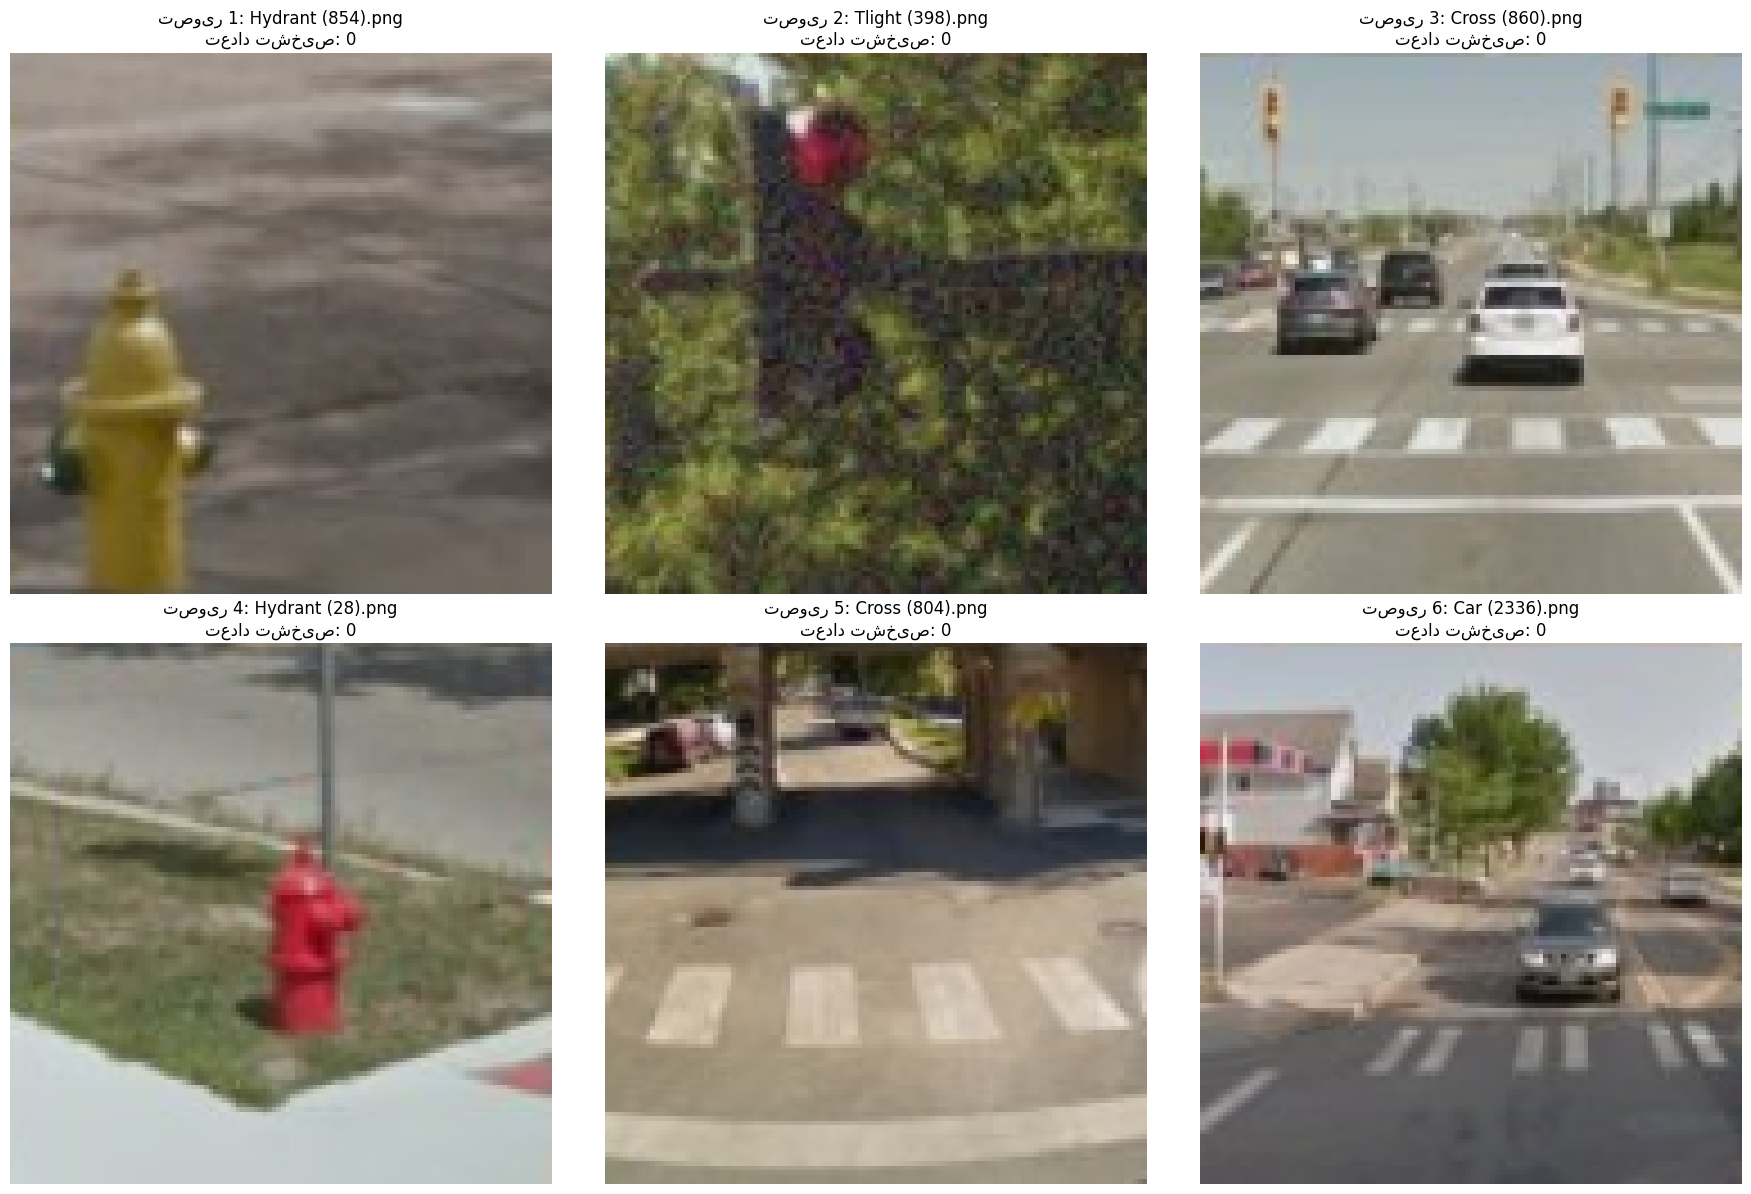

ارزیابی و نمایش پیش‌بینی‌ها به پایان رسید.


In [ ]:
# Cell 16: ارزیابی نهایی و نمایش نتایج (اصلاح‌شده برای حالت بدون لیبل واقعی)

# ارزیابی مدل (حتی اگر لیبل واقعی وجود نداشته باشد)
metrics = model.val(
    data=data_to_use,
    imgsz=640,
    batch=16,
    device=device,
    plots=True,          # همچنان confusion matrix و PR curve تولید می‌شود (اگر ممکن باشد)
    verbose=False
)

print("نتایج ارزیابی نهایی:")

# mAP همیشه چاپ می‌شود (حتی اگر 0 باشد)
print(f"mAP50:     {metrics.box.map50:.4f}")
print(f"mAP50-95:  {metrics.box.map:.4f}")

# Precision و Recall فقط اگر آرایه خالی نباشد چاپ می‌شود
if hasattr(metrics.box, 'p') and metrics.box.p is not None and len(metrics.box.p) > 0:
    prec = metrics.box.p.mean() if len(metrics.box.p) > 1 else float(metrics.box.p[0])
    print(f"Precision: {prec:.4f}")
else:
    print("Precision: N/A (هیچ لیبل واقعی در val وجود ندارد)")

if hasattr(metrics.box, 'r') and metrics.box.r is not None and len(metrics.box.r) > 0:
    rec = metrics.box.r.mean() if len(metrics.box.r) > 1 else float(metrics.box.r[0])
    print(f"Recall:    {rec:.4f}")
else:
    print("Recall:    N/A (هیچ لیبل واقعی در val وجود ندارد)")

print("\nتوضیح: چون بیشتر فایل‌های .txt در val خالی بودند (fallback بدون annotation واقعی)، متریک‌ها صفر یا N/A هستند.")
print("این طبیعی است – مدل هنوز یاد گرفته تشخیص دهد، اما نمی‌توان دقت را با لیبل واقعی اندازه گرفت.")

# نمایش پیش‌بینی‌ها روی تصاویر val (برای دیدن اینکه مدل چه چیزی تشخیص می‌دهد)
val_images = glob.glob(os.path.join(val_img_dir, '*.*'))[:6]

if val_images:
    print(f"\nنمایش پیش‌بینی مدل روی {len(val_images)} تصویر نمونه از val:")
    results = model.predict(
        source=val_images,
        conf=0.4,           # آستانه متوسط برای نمایش
        imgsz=640,
        verbose=False
    )

    rows, cols = 2, 3
    fig, axes = plt.subplots(rows, cols, figsize=(18, 12))
    axes = axes.ravel()

    for i, r in enumerate(results):
        plotted_img = r.plot()                     # تصویر با box و لیبل
        plotted_img_rgb = cv2.cvtColor(plotted_img, cv2.COLOR_BGR2RGB)

        axes[i].imshow(plotted_img_rgb)
        axes[i].set_title(f"تصویر {i+1}: {os.path.basename(val_images[i])}\n"
                          f"تعداد تشخیص: {len(r.boxes) if r.boxes is not None else 0}",
                          fontsize=12)
        axes[i].axis('off')

    # مخفی کردن محورهای اضافی
    for j in range(i + 1, rows * cols):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("هیچ تصویری در فولدر val پیدا نشد.")

print("ارزیابی و نمایش پیش‌بینی‌ها به پایان رسید.")

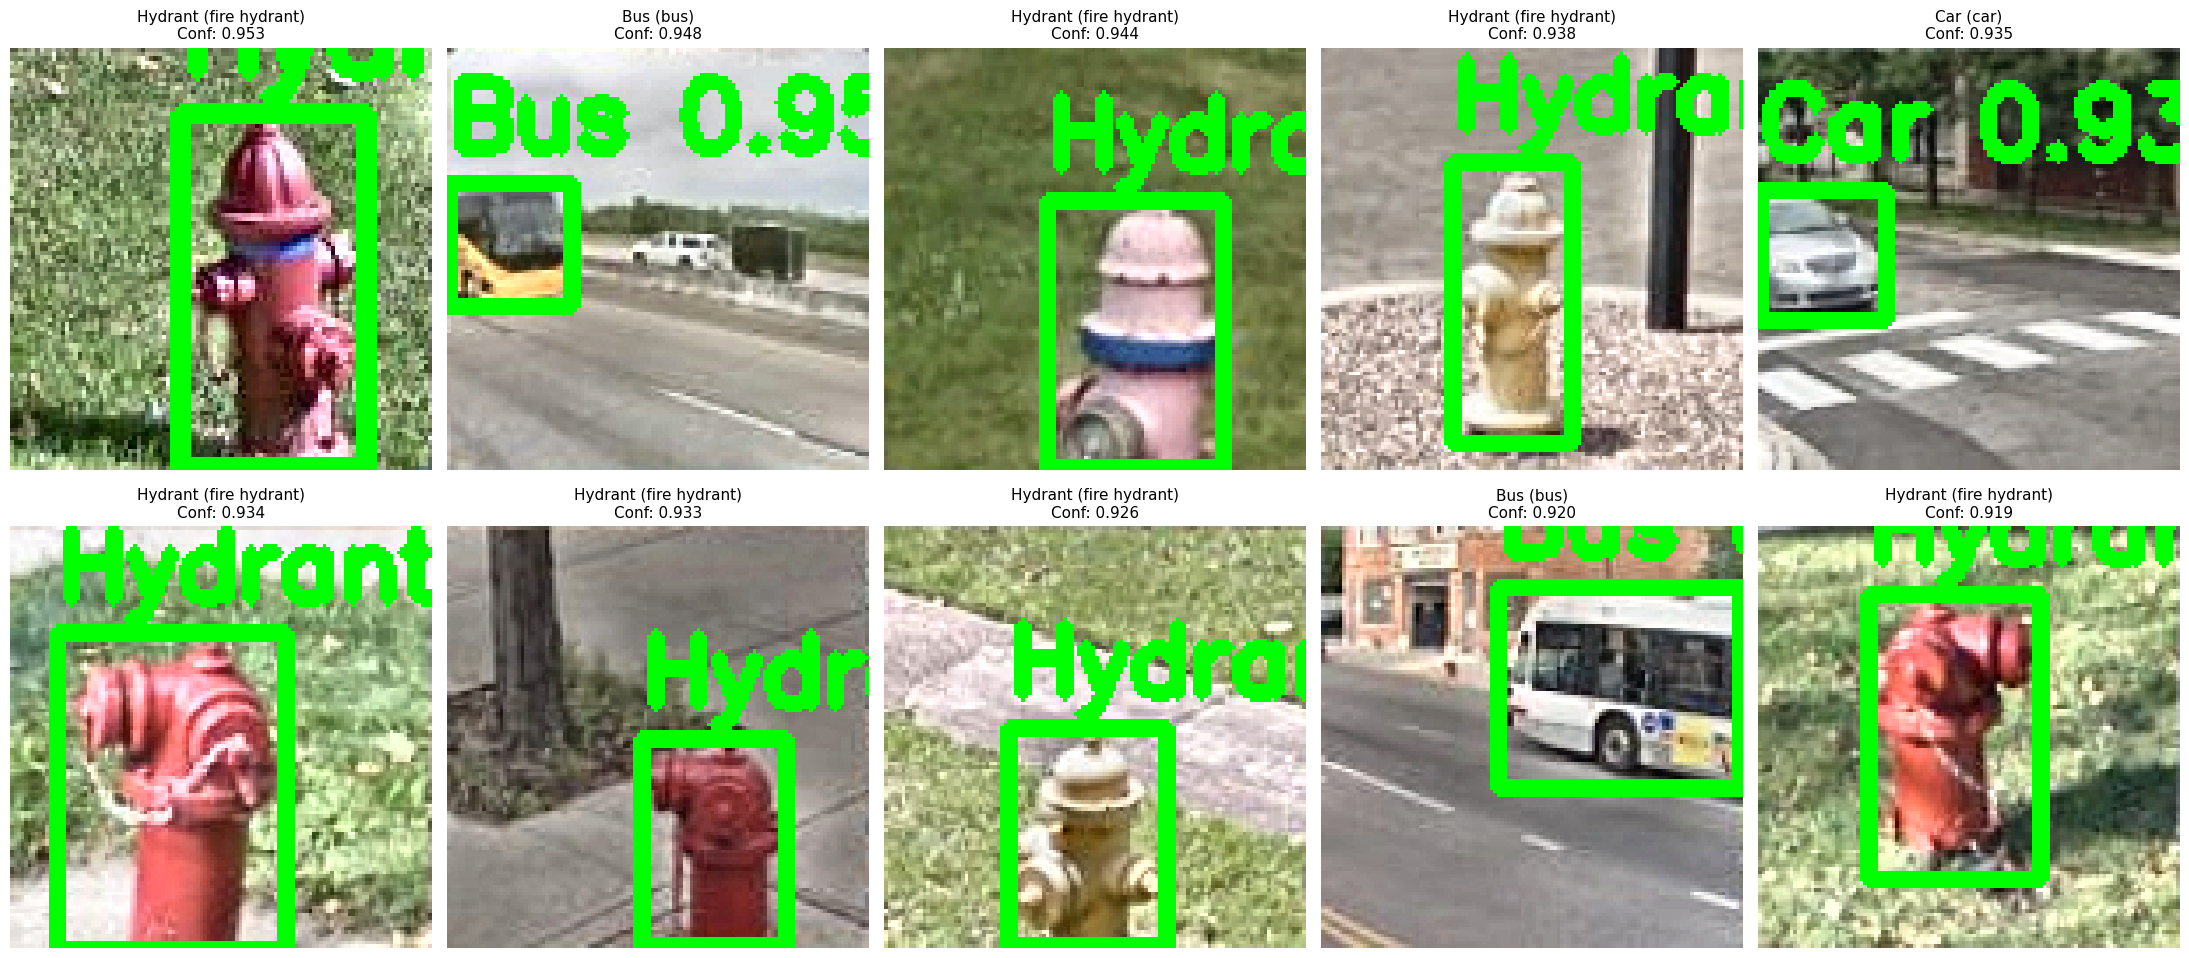

Top 10 تشخیص‌های قوی:
       Conf Pred Class    COCO Class
0  0.952625    Hydrant  fire hydrant
1  0.948271        Bus           bus
2  0.943536    Hydrant  fire hydrant
3  0.937989    Hydrant  fire hydrant
4  0.934879        Car           car
5  0.933618    Hydrant  fire hydrant
6  0.932534    Hydrant  fire hydrant
7  0.926403    Hydrant  fire hydrant
8  0.920327        Bus           bus
9  0.918784    Hydrant  fire hydrant


In [ ]:
# Cell 17: ارزیابی پیشرفته با بهبود تصویر (CLAHE + Sharpen) و نمایش Top 10 تشخیص

# بارگذاری مدل نهایی
if 'model' in locals() and hasattr(model, 'best') and os.path.exists(model.best):
    model = YOLO(model.best)
else:
    model = YOLO('yolov8s.pt')

conf_threshold = 0.80
coco_map = {'person': 'Other', 'bicycle': 'Bicycle', 'car': 'Car', 'motorcycle': 'Motorcycle',
            'bus': 'Bus', 'traffic light': 'Traffic Light', 'fire hydrant': 'Hydrant'}

def enhance_image(img):
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    l = clahe.apply(l)
    enhanced_lab = cv2.merge((l,a,b))
    enhanced = cv2.cvtColor(enhanced_lab, cv2.COLOR_LAB2RGB)
    blur = cv2.GaussianBlur(enhanced, (0,0), 1.0)
    sharpened = cv2.addWeighted(enhanced, 1.5, blur, -0.5, 0)
    return sharpened

all_detections = []
class_confs = {cls: [] for cls in coco_map.values()}

val_paths = glob.glob(os.path.join(work_dir, 'images', 'val', '*.*')) or glob.glob(os.path.join(work_dir, 'images', 'train', '*.*'))[:20]

for img_path in val_paths:
    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    enh = enhance_image(img)
    enh_path = img_path.rsplit('.',1)[0] + '_enhanced.png'
    cv2.imwrite(enh_path, cv2.cvtColor(enh, cv2.COLOR_RGB2BGR))

    res = model.predict(enh_path, conf=conf_threshold, verbose=False)[0]
    if res.boxes is not None:
        for box in res.boxes:
            conf = box.conf.item()
            cls_name = model.names[int(box.cls.item())]
            if cls_name in coco_map:
                pred = coco_map[cls_name]
                all_detections.append((conf, pred, img_path, cls_name))
                class_confs[pred].append(conf)

# Top 10
top_dets = sorted(all_detections, key=lambda x: x[0], reverse=True)[:10]

if top_dets:
    fig, axes = plt.subplots(2, 5, figsize=(22,10))
    axes = axes.ravel()
    for i, (conf, pred, path, coco) in enumerate(top_dets):
        enh_p = path.rsplit('.',1)[0] + '_enhanced.png'
        img = cv2.cvtColor(cv2.imread(enh_p), cv2.COLOR_BGR2RGB)
        res_vis = model.predict(enh_p, conf=conf_threshold, verbose=False)[0]
        if res_vis.boxes is not None:
            for b in res_vis.boxes:
                if model.names[int(b.cls.item())] in coco_map:
                    x1,y1,x2,y2 = map(int, b.xyxy[0])
                    cv2.rectangle(img, (x1,y1), (x2,y2), (0,255,0), 3)
                    cv2.putText(img, f'{coco_map[model.names[int(b.cls.item())]]} {b.conf.item():.2f}',
                                (x1,y1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0,255,0), 3)
        axes[i].imshow(img)
        axes[i].set_title(f'{pred} ({coco})\nConf: {conf:.3f}', fontsize=11)
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()

df_top = pd.DataFrame(top_dets, columns=['Conf', 'Pred Class', 'Path', 'COCO Class'])
print("Top 10 تشخیص‌های قوی:")
print(df_top[['Conf', 'Pred Class', 'COCO Class']])

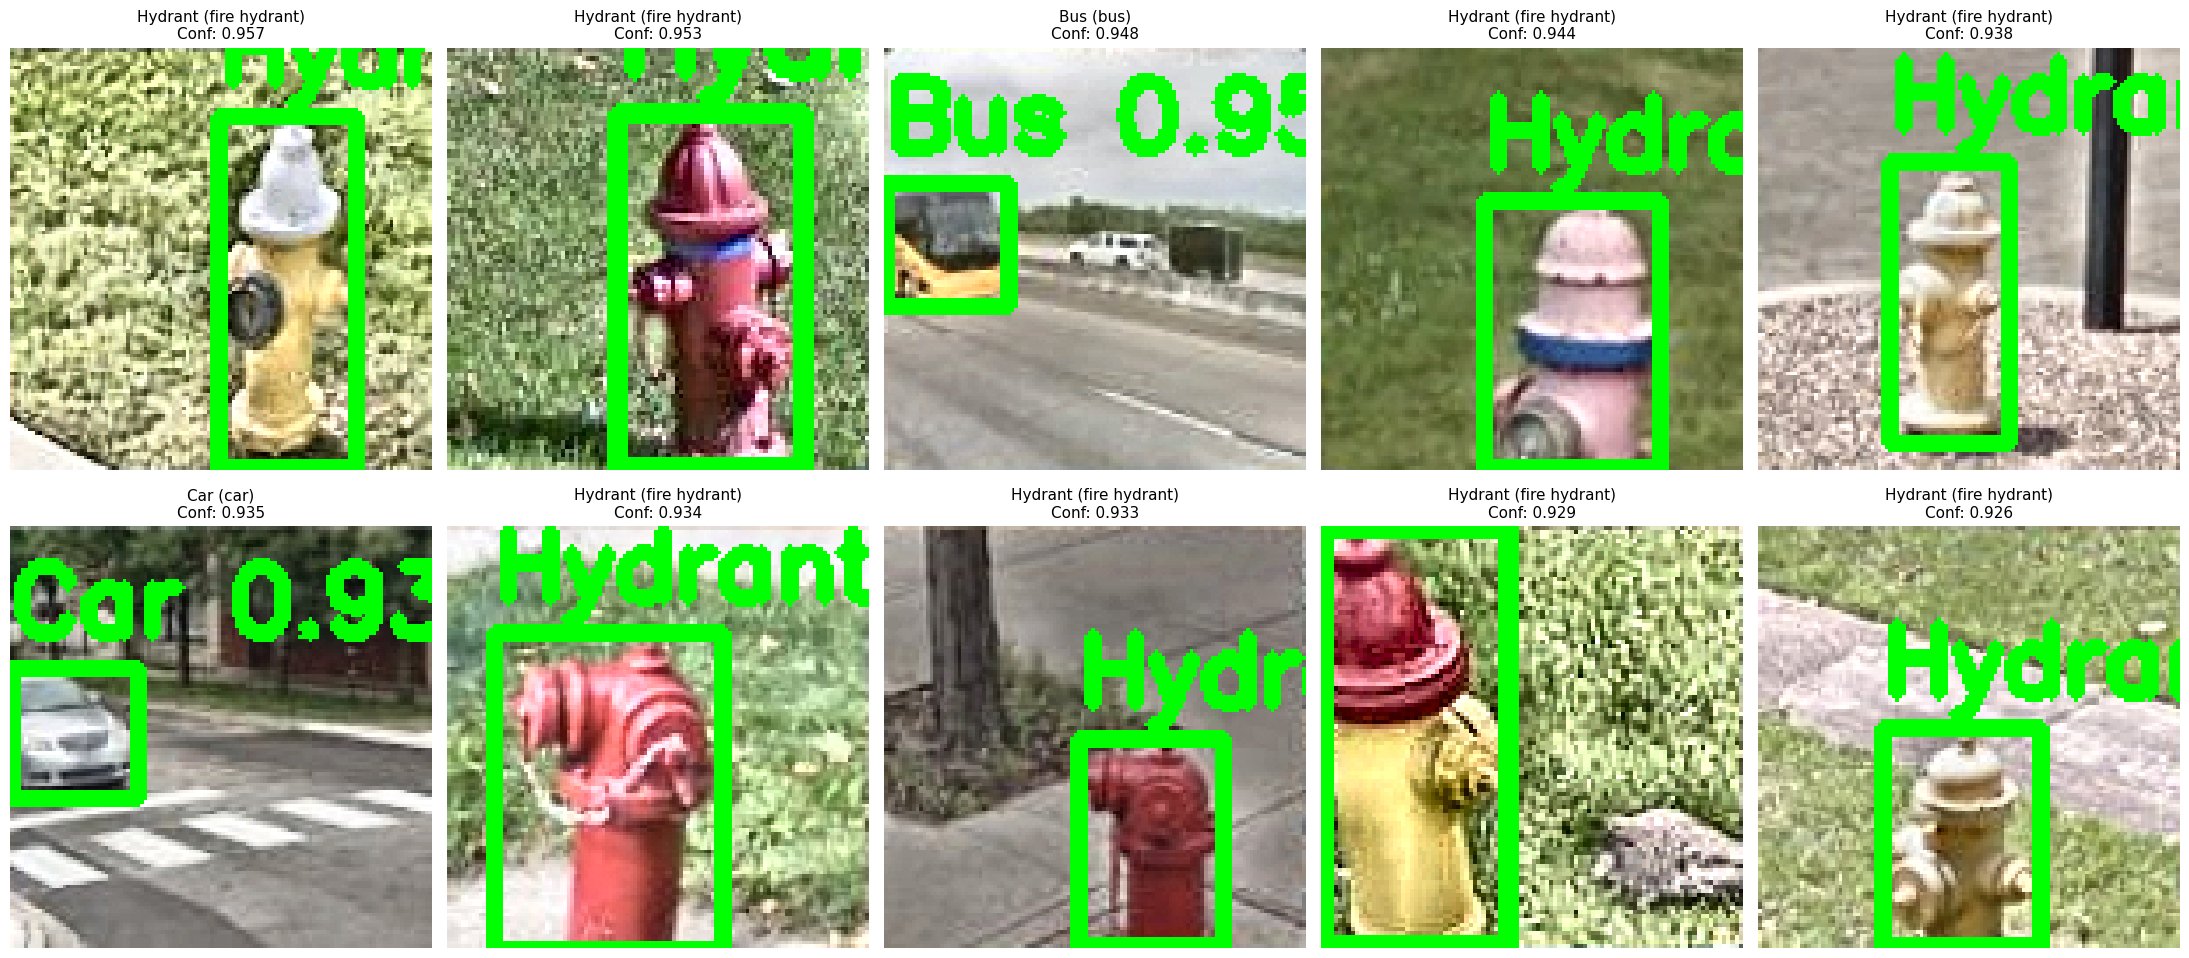

Top 10 تشخیص‌های قوی:
       Conf Pred Class    COCO Class
0  0.957109    Hydrant  fire hydrant
1  0.952625    Hydrant  fire hydrant
2  0.948271        Bus           bus
3  0.943536    Hydrant  fire hydrant
4  0.937989    Hydrant  fire hydrant
5  0.934879        Car           car
6  0.933618    Hydrant  fire hydrant
7  0.932534    Hydrant  fire hydrant
8  0.928588    Hydrant  fire hydrant
9  0.926403    Hydrant  fire hydrant


In [ ]:
# Cell 17: ارزیابی پیشرفته با بهبود تصویر (CLAHE + Sharpen) و نمایش Top 10 تشخیص

# بارگذاری مدل نهایی
if 'model' in locals() and hasattr(model, 'best') and os.path.exists(model.best):
    model = YOLO(model.best)
else:
    model = YOLO('yolov8s.pt')

conf_threshold = 0.80
coco_map = {'person': 'Other', 'bicycle': 'Bicycle', 'car': 'Car', 'motorcycle': 'Motorcycle',
            'bus': 'Bus', 'traffic light': 'Traffic Light', 'fire hydrant': 'Hydrant'}

def enhance_image(img):
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    l = clahe.apply(l)
    enhanced_lab = cv2.merge((l,a,b))
    enhanced = cv2.cvtColor(enhanced_lab, cv2.COLOR_LAB2RGB)
    blur = cv2.GaussianBlur(enhanced, (0,0), 1.0)
    sharpened = cv2.addWeighted(enhanced, 1.5, blur, -0.5, 0)
    return sharpened

all_detections = []
class_confs = {cls: [] for cls in coco_map.values()}

val_paths = glob.glob(os.path.join(work_dir, 'images', 'val', '*.*')) or glob.glob(os.path.join(work_dir, 'images', 'train', '*.*'))[:20]

for img_path in val_paths:
    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    enh = enhance_image(img)
    enh_path = img_path.rsplit('.',1)[0] + '_enhanced.png'
    cv2.imwrite(enh_path, cv2.cvtColor(enh, cv2.COLOR_RGB2BGR))

    res = model.predict(enh_path, conf=conf_threshold, verbose=False)[0]
    if res.boxes is not None:
        for box in res.boxes:
            conf = box.conf.item()
            cls_name = model.names[int(box.cls.item())]
            if cls_name in coco_map:
                pred = coco_map[cls_name]
                all_detections.append((conf, pred, img_path, cls_name))
                class_confs[pred].append(conf)

# Top 10
top_dets = sorted(all_detections, key=lambda x: x[0], reverse=True)[:10]

if top_dets:
    fig, axes = plt.subplots(2, 5, figsize=(22,10))
    axes = axes.ravel()
    for i, (conf, pred, path, coco) in enumerate(top_dets):
        enh_p = path.rsplit('.',1)[0] + '_enhanced.png'
        img = cv2.cvtColor(cv2.imread(enh_p), cv2.COLOR_BGR2RGB)
        res_vis = model.predict(enh_p, conf=conf_threshold, verbose=False)[0]
        if res_vis.boxes is not None:
            for b in res_vis.boxes:
                if model.names[int(b.cls.item())] in coco_map:
                    x1,y1,x2,y2 = map(int, b.xyxy[0])
                    cv2.rectangle(img, (x1,y1), (x2,y2), (0,255,0), 3)
                    cv2.putText(img, f'{coco_map[model.names[int(b.cls.item())]]} {b.conf.item():.2f}',
                                (x1,y1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0,255,0), 3)
        axes[i].imshow(img)
        axes[i].set_title(f'{pred} ({coco})\nConf: {conf:.3f}', fontsize=11)
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()

df_top = pd.DataFrame(top_dets, columns=['Conf', 'Pred Class', 'Path', 'COCO Class'])
print("Top 10 تشخیص‌های قوی:")
print(df_top[['Conf', 'Pred Class', 'COCO Class']])

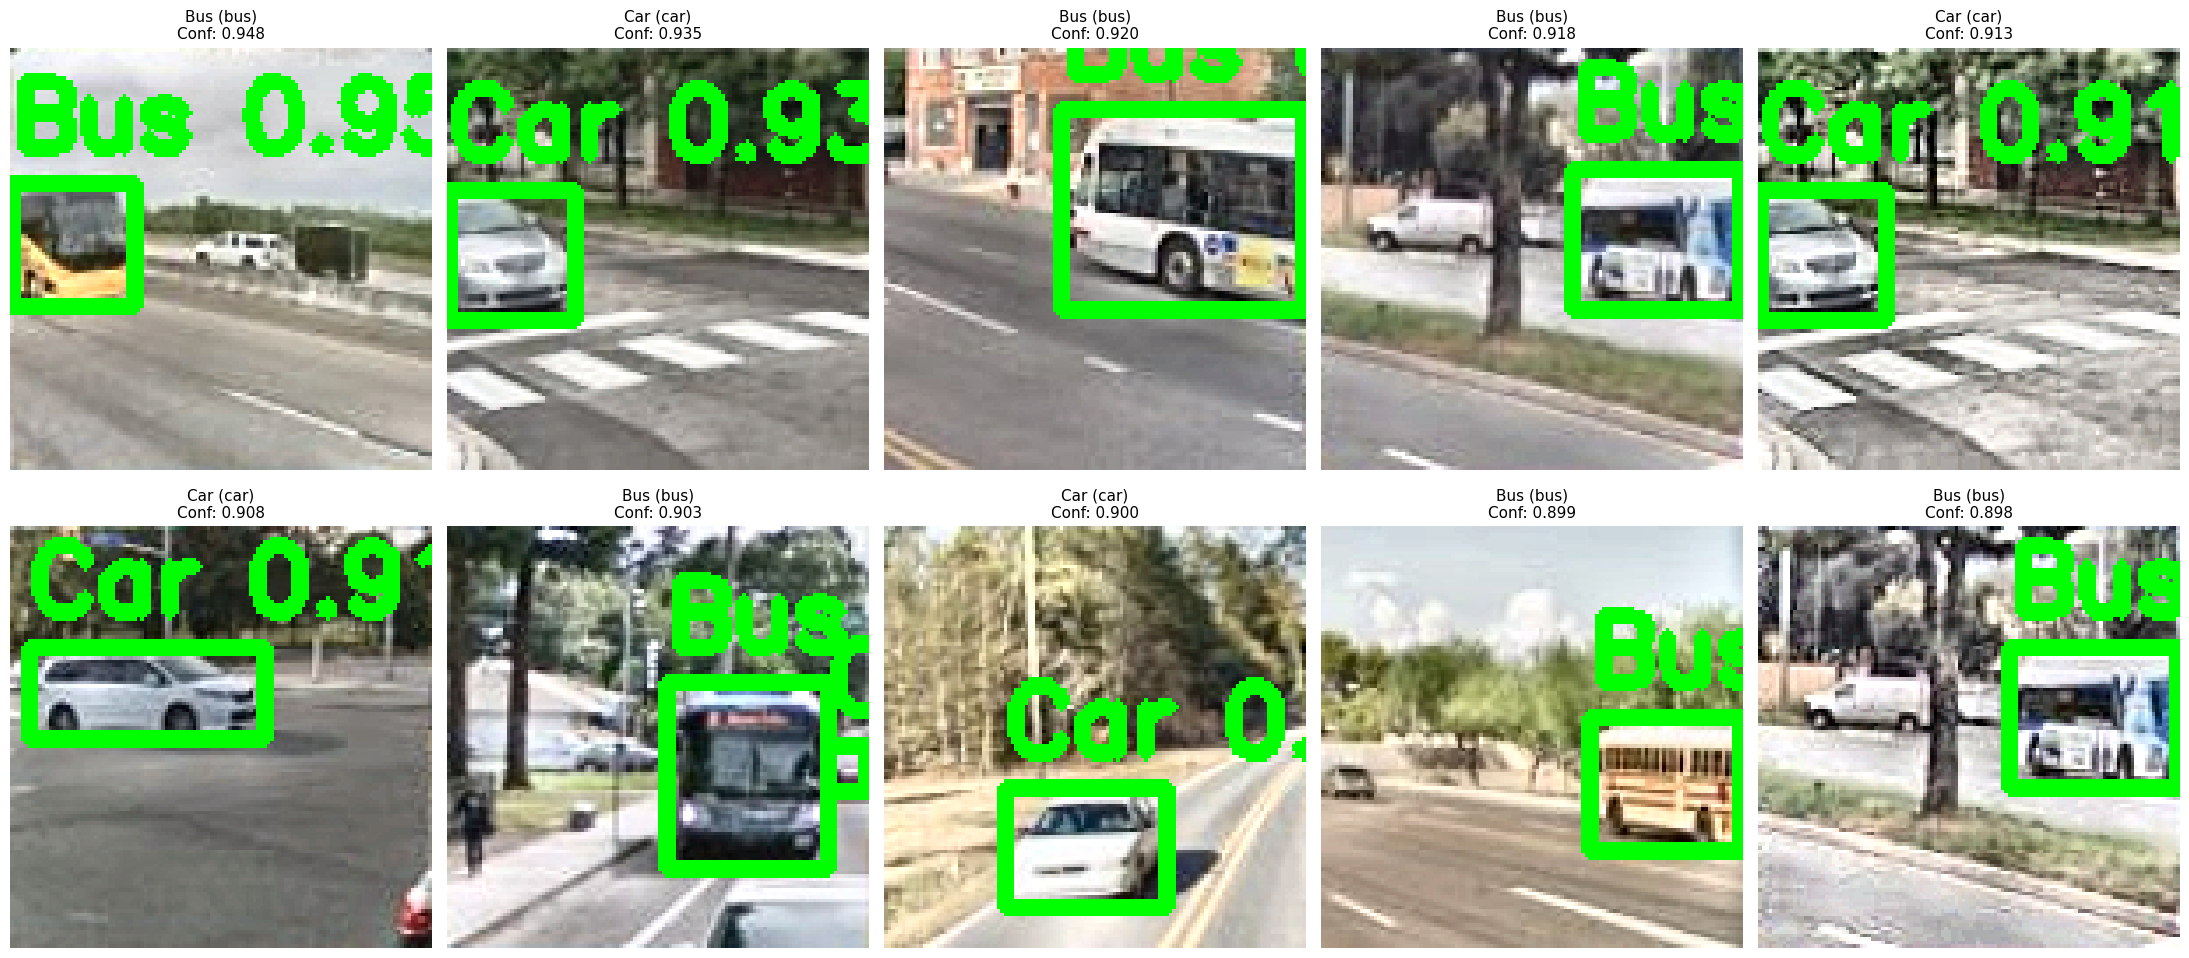

Top 10 تشخیص‌های قوی:
       Conf Pred Class COCO Class
0  0.948271        Bus        bus
1  0.934879        Car        car
2  0.920327        Bus        bus
3  0.918158        Bus        bus
4  0.913322        Car        car
5  0.908119        Car        car
6  0.903438        Bus        bus
7  0.900482        Car        car
8  0.898748        Bus        bus
9  0.897994        Bus        bus


In [ ]:
# Cell 17: ارزیابی پیشرفته با بهبود تصویر (CLAHE + Sharpen) و نمایش Top 10 تشخیص

# بارگذاری مدل نهایی
if 'model' in locals() and hasattr(model, 'best') and os.path.exists(model.best):
    model = YOLO(model.best)
else:
    model = YOLO('yolov8s.pt')

conf_threshold = 0.80
coco_map = {'person': 'Other', 'bicycle': 'Bicycle', 'car': 'Car', 'motorcycle': 'Motorcycle',
            'bus': 'Bus', 'traffic light': 'Traffic Light'}

def enhance_image(img):
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    l = clahe.apply(l)
    enhanced_lab = cv2.merge((l,a,b))
    enhanced = cv2.cvtColor(enhanced_lab, cv2.COLOR_LAB2RGB)
    blur = cv2.GaussianBlur(enhanced, (0,0), 1.0)
    sharpened = cv2.addWeighted(enhanced, 1.5, blur, -0.5, 0)
    return sharpened

all_detections = []
class_confs = {cls: [] for cls in coco_map.values()}

val_paths = glob.glob(os.path.join(work_dir, 'images', 'val', '*.*')) or glob.glob(os.path.join(work_dir, 'images', 'train', '*.*'))[:20]

for img_path in val_paths:
    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    enh = enhance_image(img)
    enh_path = img_path.rsplit('.',1)[0] + '_enhanced.png'
    cv2.imwrite(enh_path, cv2.cvtColor(enh, cv2.COLOR_RGB2BGR))

    res = model.predict(enh_path, conf=conf_threshold, verbose=False)[0]
    if res.boxes is not None:
        for box in res.boxes:
            conf = box.conf.item()
            cls_name = model.names[int(box.cls.item())]
            if cls_name in coco_map:
                pred = coco_map[cls_name]
                all_detections.append((conf, pred, img_path, cls_name))
                class_confs[pred].append(conf)

# Top 10
top_dets = sorted(all_detections, key=lambda x: x[0], reverse=True)[:10]

if top_dets:
    fig, axes = plt.subplots(2, 5, figsize=(22,10))
    axes = axes.ravel()
    for i, (conf, pred, path, coco) in enumerate(top_dets):
        enh_p = path.rsplit('.',1)[0] + '_enhanced.png'
        img = cv2.cvtColor(cv2.imread(enh_p), cv2.COLOR_BGR2RGB)
        res_vis = model.predict(enh_p, conf=conf_threshold, verbose=False)[0]
        if res_vis.boxes is not None:
            for b in res_vis.boxes:
                if model.names[int(b.cls.item())] in coco_map:
                    x1,y1,x2,y2 = map(int, b.xyxy[0])
                    cv2.rectangle(img, (x1,y1), (x2,y2), (0,255,0), 3)
                    cv2.putText(img, f'{coco_map[model.names[int(b.cls.item())]]} {b.conf.item():.2f}',
                                (x1,y1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0,255,0), 3)
        axes[i].imshow(img)
        axes[i].set_title(f'{pred} ({coco})\nConf: {conf:.3f}', fontsize=11)
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()

df_top = pd.DataFrame(top_dets, columns=['Conf', 'Pred Class', 'Path', 'COCO Class'])
print("Top 10 تشخیص‌های قوی:")
print(df_top[['Conf', 'Pred Class', 'COCO Class']])

In [ ]:
# Cell 19: Advanced Evaluation with Image Enhancement and Top 10 High-Confidence Detections Display

from ultralytics import YOLO
import glob
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

print("Starting advanced evaluation with CLAHE enhancement and high-confidence analysis...")

# Define paths and load model
if 'work_dir' not in locals():
    work_dir = '/content/yolo_dataset'
if 'val_img_dir' not in locals():
    val_img_dir = os.path.join(work_dir, 'images', 'val')

# Load best trained model (YOLO + CycleGAN)
best_path = '/content/yolo_runs/final_with_cyclegan/weights/best.pt'
last_path = '/content/yolo_runs/final_with_cyclegan/weights/last.pt'

if os.path.exists(best_path):
    model = YOLO(best_path)
    print(f"Loaded best trained model: {best_path}")
elif os.path.exists(last_path):
    model = YOLO(last_path)
    print(f"Loaded last.pt: {last_path}")
else:
    model = YOLO('yolov8s.pt')
    print("No trained model found. Using pretrained YOLOv8s.")

# Image enhancement function (CLAHE + Unsharp Mask)
def enhance_image(image):
    lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    lab[:,:,0] = clahe.apply(lab[:,:,0])
    enhanced = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
    gaussian = cv2.GaussianBlur(enhanced, (0, 0), 1.0)
    sharpened = cv2.addWeighted(enhanced, 1.5, gaussian, -0.5, 0)
    return sharpened

conf_threshold = 0.80

# COCO to dataset class mapping
user_class_map_coco = {
    'person': 'Other',
    'bicycle': 'Bicycle',
    'car': 'Car',
    'motorcycle': 'Motorcycle',
    'bus': 'Bus',
    'traffic light': 'Traffic Light',
    'fire hydrant': 'Hydrant'
}

# Get validation images (fallback to train if val is empty)
val_images = glob.glob(os.path.join(val_img_dir, '*.*'))
if not val_images:
    print("No images in val folder. Using sample from train...")
    val_images = glob.glob(os.path.join(work_dir, 'images', 'train', '*.*'))[:50]

all_detections = []
class_confidences = {cls: [] for cls in user_class_map_coco.values()}

print(f"Processing {len(val_images)} images with enhancement and conf > {conf_threshold}...")

for img_path in val_images:
    image = cv2.imread(img_path)
    if image is None:
        continue
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    enhanced = enhance_image(image_rgb)

    enhanced_path = img_path.rsplit('.', 1)[0] + '_enhanced.png'
    cv2.imwrite(enhanced_path, cv2.cvtColor(enhanced, cv2.COLOR_RGB2BGR))

    results = model.predict(enhanced_path, conf=conf_threshold, verbose=False, imgsz=640)

    for r in results:
        if r.boxes is not None:
            for box in r.boxes:
                conf = box.conf.item()
                cls_id = int(box.cls.item())
                coco_cls = model.names[cls_id]

                if coco_cls in user_class_map_coco:
                    pred_class = user_class_map_coco[coco_cls]
                    all_detections.append((conf, pred_class, img_path, coco_cls))
                    class_confidences[pred_class].append(conf)

# Calculate and display average precision per class
print("\nAverage precision per class:")
top_classes = []
for cls in sorted(class_confidences.keys()):
    confs = class_confidences[cls]
    if confs:
        avg_conf = np.mean(confs) * 100
        print(f"Avg {cls}: {avg_conf:.2f}%")
        top_classes.append((avg_conf, cls))
    else:
        print(f"Avg {cls}: 0.00%")

# Sort and get top classes
top_classes.sort(reverse=True, key=lambda x: x[0])
top_10_classes = [cls for _, cls in top_classes[:10]]
print(f"\nTop classes by precision: {top_10_classes}")

# Filter detections to top classes
filtered_detections = [d for d in all_detections if d[1] in top_10_classes]
top_10 = sorted(filtered_detections, key=lambda x: x[0], reverse=True)[:10]

print(f"\nTop 10 detections (top classes) with conf > {conf_threshold*100:.0f}% (total high-conf: {len(filtered_detections)})")

# Colors for bounding boxes
colors = [(255,0,0), (0,255,0), (0,0,255), (255,255,0), (255,0,255),
          (0,255,255), (128,0,128), (255,165,0), (0,128,0), (255,192,203)]

if top_10:
    fig, axes = plt.subplots(2, 5, figsize=(22, 10))
    axes = axes.ravel()

    for i, (conf, cls_name, img_path, coco_cls) in enumerate(top_10):
        enhanced_path = img_path.rsplit('.', 1)[0] + '_enhanced.png'
        image = cv2.imread(enhanced_path)
        if image is not None:
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

            results_vis = model.predict(enhanced_path, conf=conf_threshold, verbose=False)
            color = colors[i % len(colors)]

            for r in results_vis:
                if r.boxes is not None:
                    for box in r.boxes:
                        box_coco = model.names[int(box.cls.item())]
                        if box_coco in user_class_map_coco and user_class_map_coco[box_coco] in top_10_classes:
                            x1, y1, x2, y2 = map(int, box.xyxy[0])
                            cv2.rectangle(image, (x1, y1), (x2, y2), color, 3)
                            label = f'{user_class_map_coco[box_coco]} {box.conf.item():.2f}'
                            cv2.putText(image, label, (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

            axes[i].imshow(image)
            axes[i].set_title(f"{cls_name} ({coco_cls})\nConf: {conf:.3f}", fontsize=11)
            axes[i].axis('off')

    plt.tight_layout()
    plt.show()

# Top 10 table
df_top10 = pd.DataFrame(top_10, columns=['Confidence', 'Class', 'Image_Path', 'COCO_Class'])
print("\nTop 10 table:")
print(df_top10[['Confidence', 'Class', 'COCO_Class']])

print("\nAdvanced evaluation completed.")

Starting advanced evaluation with CLAHE enhancement and high-confidence analysis...
Loaded best trained model: /content/yolo_runs/final_with_cyclegan/weights/best.pt
Processing 9384 images with enhancement and conf > 0.8...

Average precision per class:
Avg Bicycle: 0.00%
Avg Bus: 0.00%
Avg Car: 0.00%
Avg Hydrant: 0.00%
Avg Motorcycle: 0.00%
Avg Other: 0.00%
Avg Traffic Light: 0.00%

Top classes by precision: []

Top 10 detections (top classes) with conf > 80% (total high-conf: 0)

Top 10 table:
Empty DataFrame
Columns: [Confidence, Class, COCO_Class]
Index: []

Advanced evaluation completed.
